In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('netflix_titles.csv')

print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [4]:
print("Shape of Dataset:", df.shape)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset: (8807, 12)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating            

In [5]:
print("Summary Statistics:")
print(df.describe(include='all'))

Summary Statistics:
       show_id   type   title       director                cast  \
count     8807   8807    8807           6173                7982   
unique    8807      2    8807           4528                7692   
top      s8807  Movie  Zubaan  Rajiv Chilaka  David Attenborough   
freq         1   6131       1             19                  19   
mean       NaN    NaN     NaN            NaN                 NaN   
std        NaN    NaN     NaN            NaN                 NaN   
min        NaN    NaN     NaN            NaN                 NaN   
25%        NaN    NaN     NaN            NaN                 NaN   
50%        NaN    NaN     NaN            NaN                 NaN   
75%        NaN    NaN     NaN            NaN                 NaN   
max        NaN    NaN     NaN            NaN                 NaN   

              country       date_added  release_year rating  duration  \
count            7976             8797   8807.000000   8803      8804   
unique           

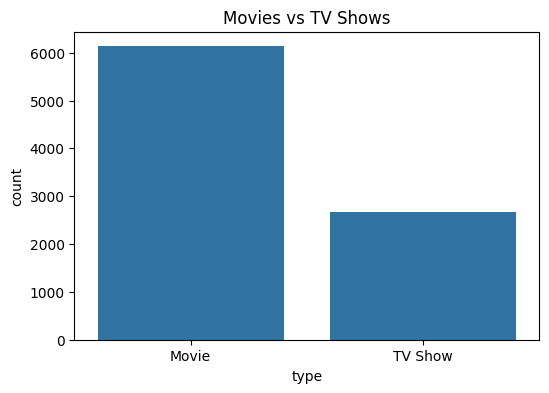

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

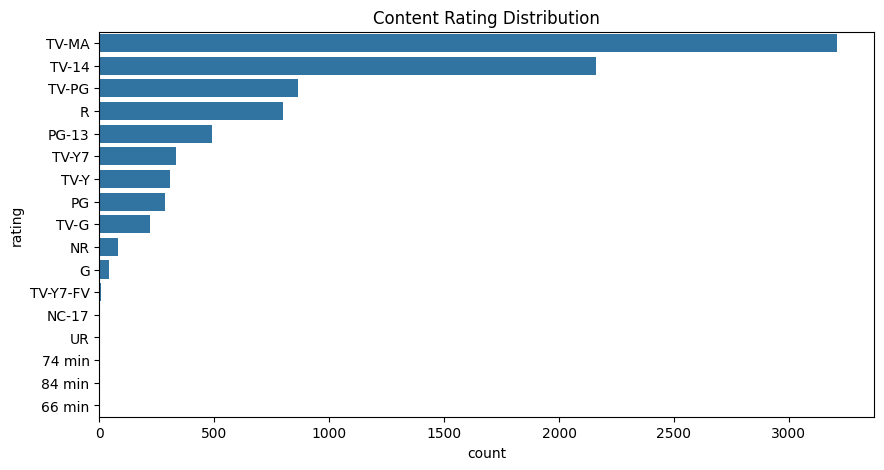

In [8]:
plt.figure(figsize=(10,5))
sns.countplot(y='rating',
              data=df,
              order=df['rating'].value_counts().index)

plt.title("Content Rating Distribution")
plt.show()

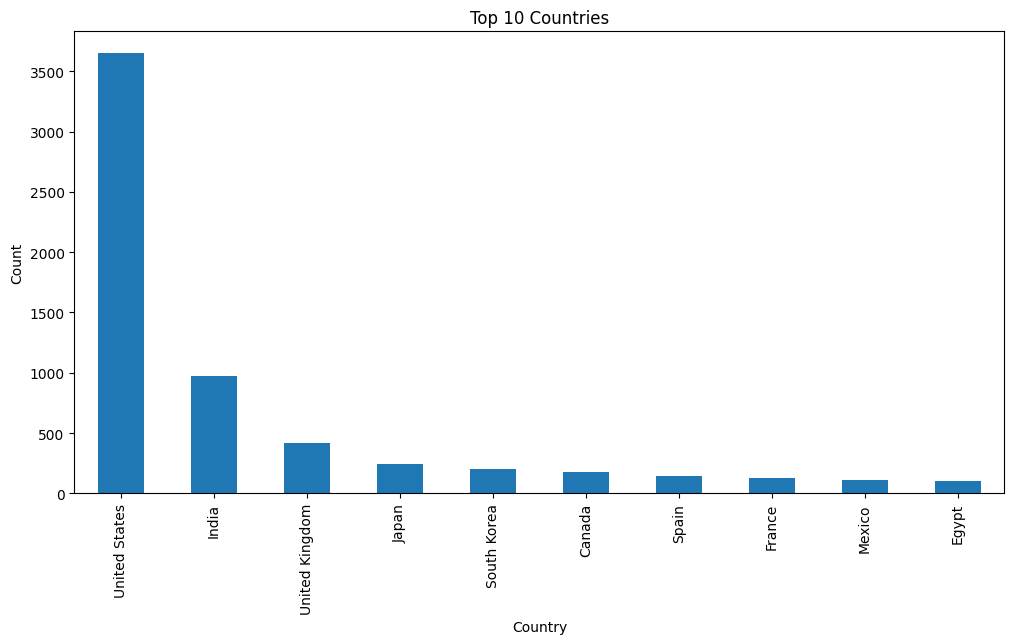

In [9]:
plt.figure(figsize=(12,6))

df['country'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

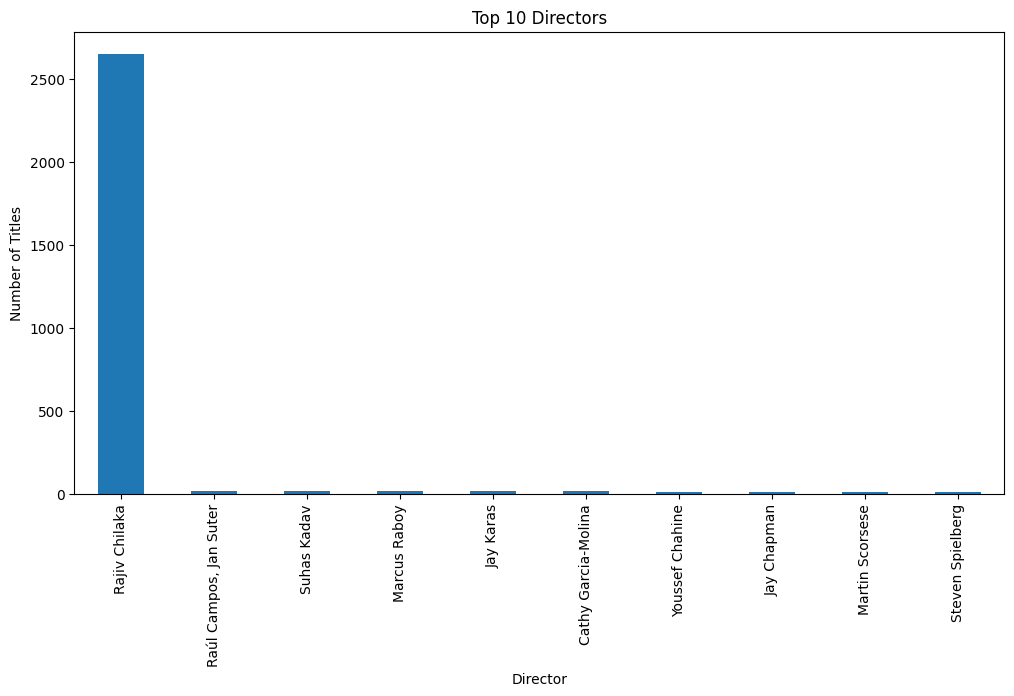

In [10]:
plt.figure(figsize=(12,6))

df['director'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Directors")
plt.xlabel("Director")
plt.ylabel("Number of Titles")
plt.show()

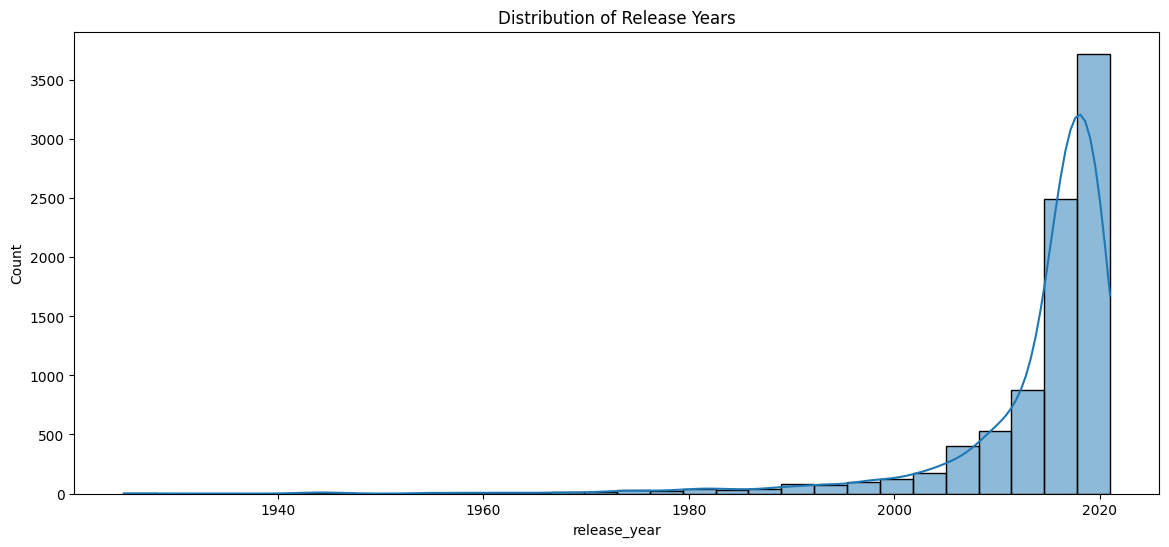

In [11]:
plt.figure(figsize=(14,6))

sns.histplot(df['release_year'], bins=30, kde=True)

plt.title("Distribution of Release Years")
plt.show()

In [13]:
cols = ['director', 'cast', 'country', 'rating']

for col in cols:
    df[col] = df[col].fillna('Unknown')

df['date_added'] = df['date_added'].fillna(df['date_added'].mode()[0])

print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
dtype: int64


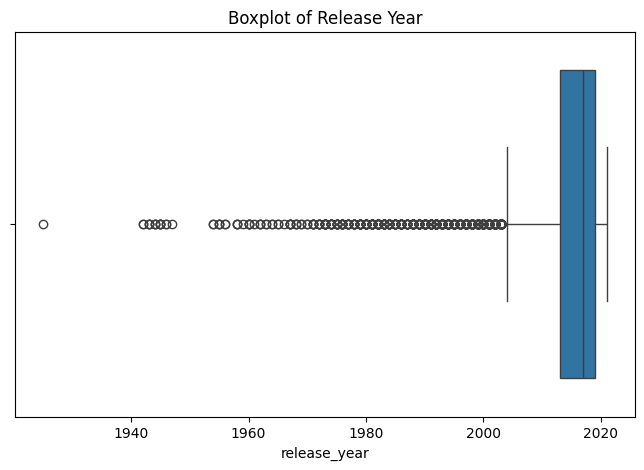

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['release_year'])

plt.title("Boxplot of Release Year")
plt.show()

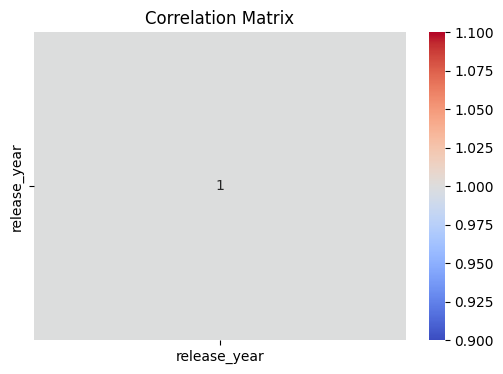

In [19]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(6,4))

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

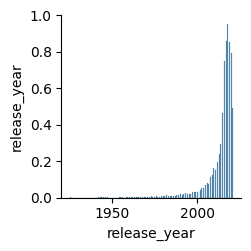

In [20]:
sns.pairplot(numeric_df)
plt.show()

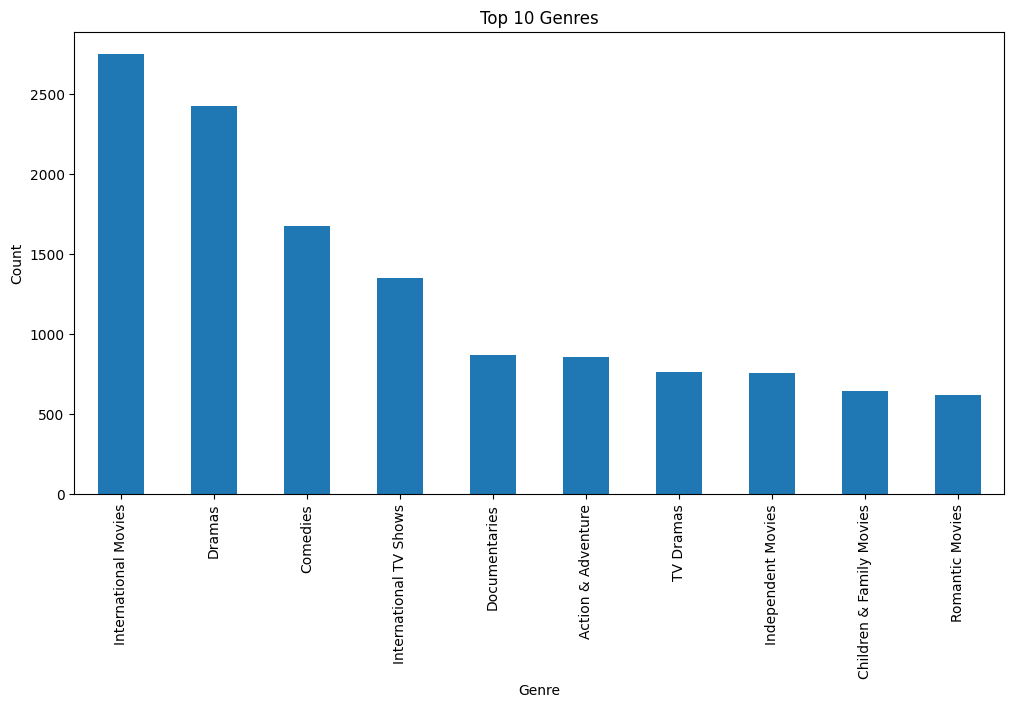

In [21]:
genres = df['listed_in'].str.split(', ').explode()

plt.figure(figsize=(12,6))

genres.value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

In [22]:
print("Skewness:")

print(df[['release_year']].skew())

Skewness:
release_year   -3.446565
dtype: float64
